In [3]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (2).csv


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [7]:
df = pd.read_csv("seasonal_agriculture_performance_dataset (2).csv")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully
Rows: 4000
Columns: 28


In [8]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [9]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [13]:
print("Columns in dataset:\n")

for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

Columns in dataset:

1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


In [14]:
missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


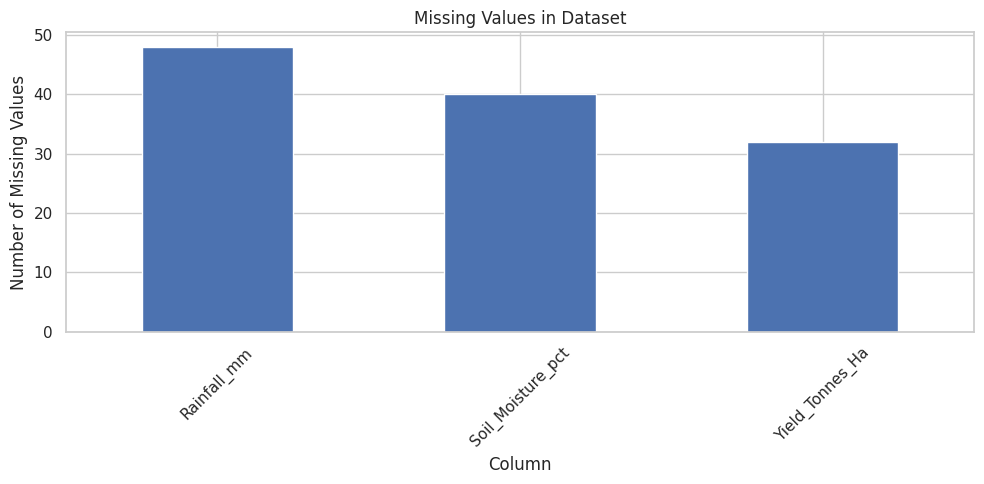

In [15]:
plt.figure(figsize=(10, 5))

missing[missing > 0].plot(kind="bar")

plt.title("Missing Values in Dataset")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [19]:
df_clean = df.copy()
numeric_columns = df_clean.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print("Total missing values after cleaning:",
      df_clean.isnull().sum().sum())

Total missing values after cleaning: 72
Total missing values after cleaning: 32
Total missing values after cleaning: 0


In [20]:
print(df_clean["Season"].value_counts())


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


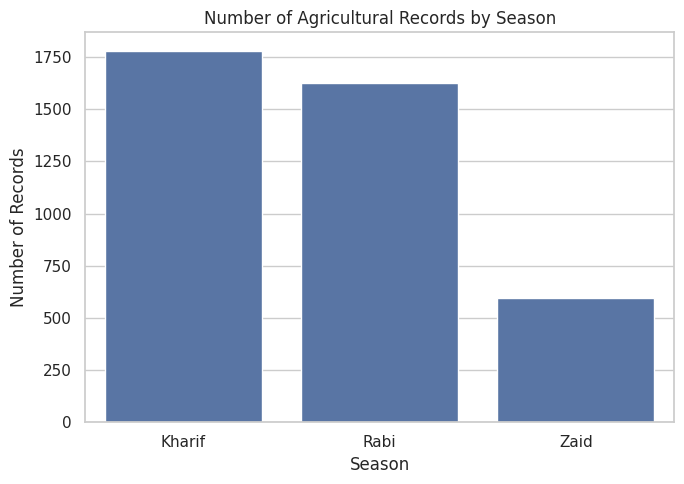

In [27]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Season"
)

plt.title("Number of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [26]:
season_summary = df_clean.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

season_summary

season_summary.to_csv("season_summary.csv")

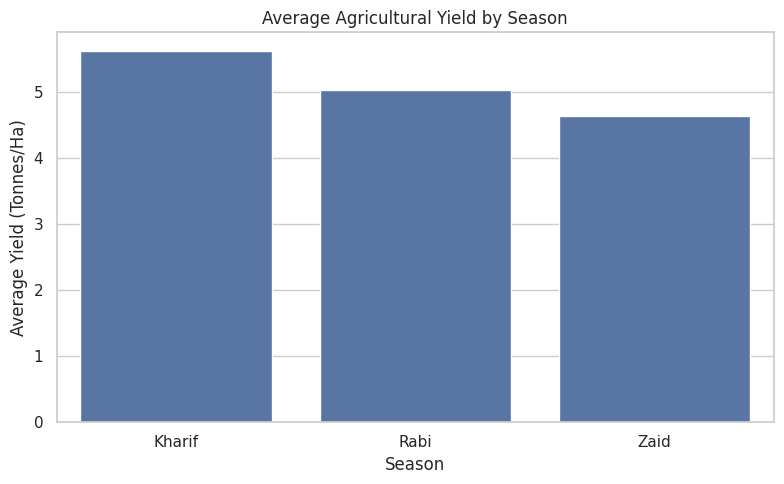

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

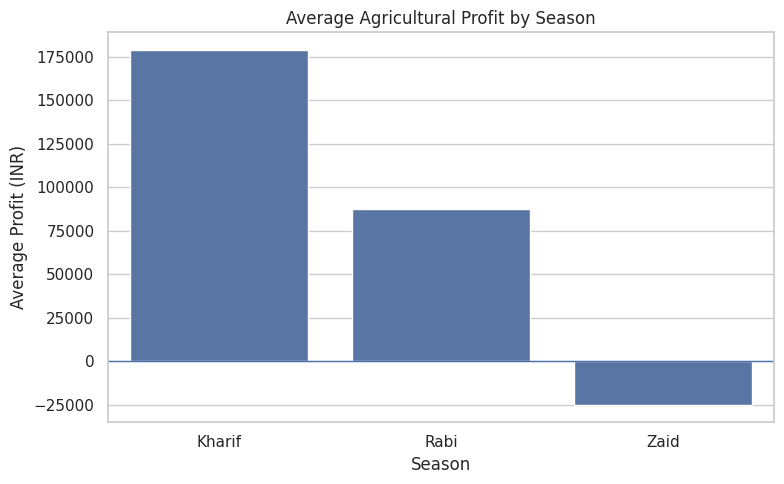

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Profit_INR",
    estimator="mean",
    errorbar=None
)

plt.axhline(0, linewidth=1)

plt.title("Average Agricultural Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.tight_layout()
plt.show()

In [29]:
environmental_summary = df_clean.groupby("Season").agg({
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Humidity_pct": "mean",
    "Sunlight_Hours_Day": "mean",
    "Soil_Moisture_pct": "mean"
}).round(2)

environmental_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


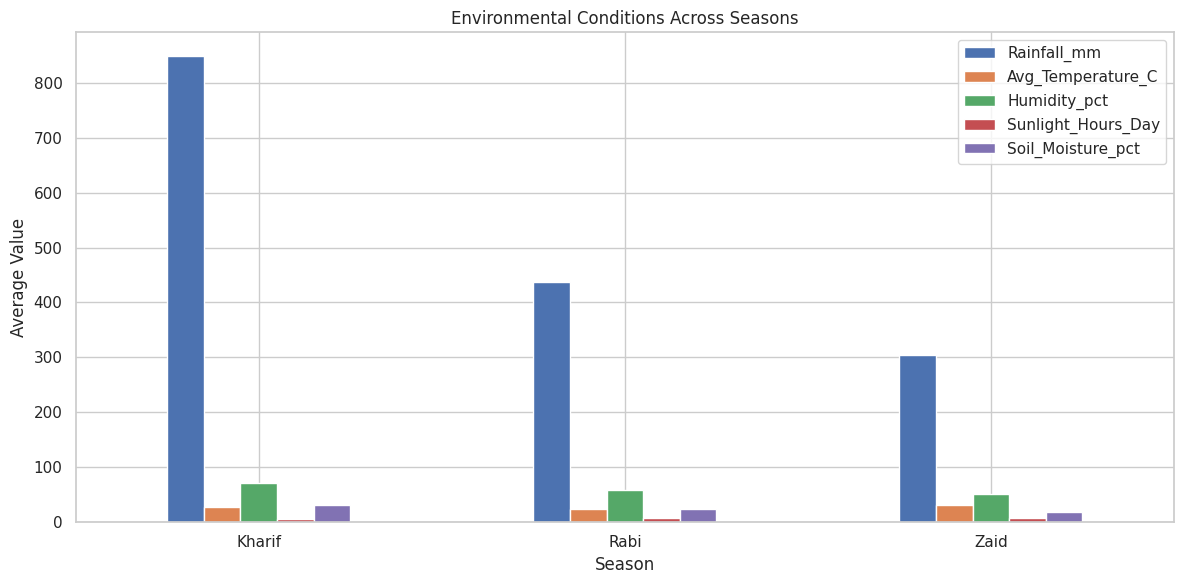

In [30]:
environmental_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Environmental Conditions Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
irrigation_summary = df_clean.groupby("Irrigation_Method").agg({
    "Yield_Tonnes_Ha": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Profit_INR": "mean"
}).round(2)

irrigation_summary

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.58,5918.75,6.27,219626.00
Flood,4.86,8026.47,3.44,73354.02
Rainfed,4.60,3549.55,7.56,79050.37
Sprinkler,5.16,6208.26,4.67,91121.08


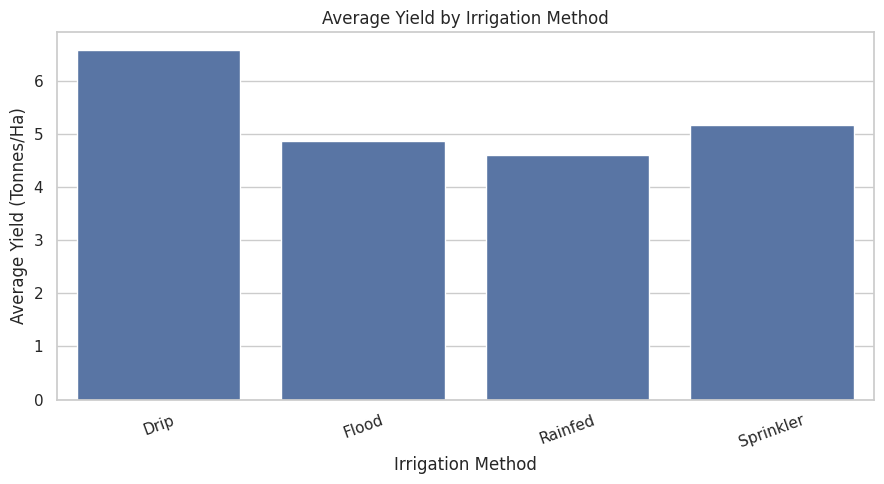

In [32]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_clean,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

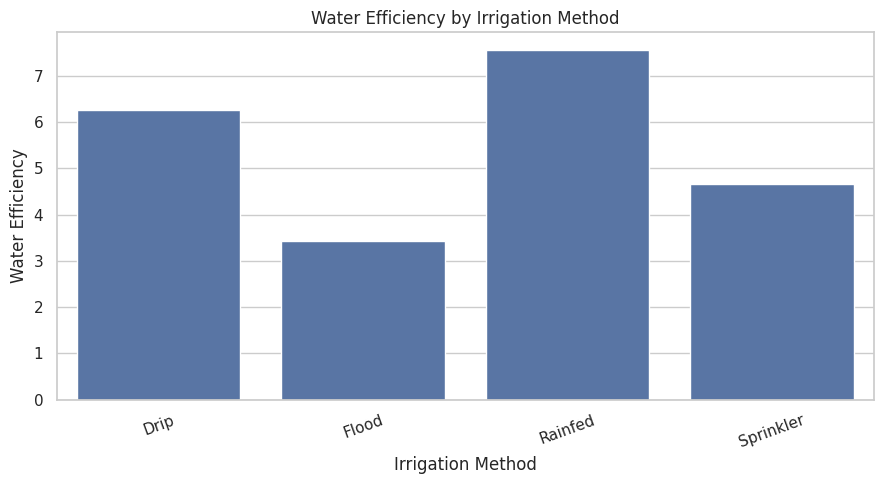

In [33]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_clean,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean",
    errorbar=None
)

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [34]:
crop_summary = df_clean.groupby("Crop").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean"
}).sort_values(
    "Profit_INR",
    ascending=False
).round(2)

crop_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Crop,,,,,
Sugarcane,46.64,392.41,1371980.11,554792.13,817187.99
Chilli,1.54,12.38,1276777.23,525898.89,750878.34
Cotton,1.23,9.40,639423.08,514876.17,124546.92
Groundnut,1.32,9.66,542935.50,498077.38,44858.12
Pulses,0.92,7.40,528465.87,532703.92,-4238.05
Maize,2.71,21.78,457067.99,541046.32,-83978.33
Rice,2.43,19.29,423615.26,525828.76,-102213.50
Wheat,2.11,16.85,400104.89,523503.22,-123398.34


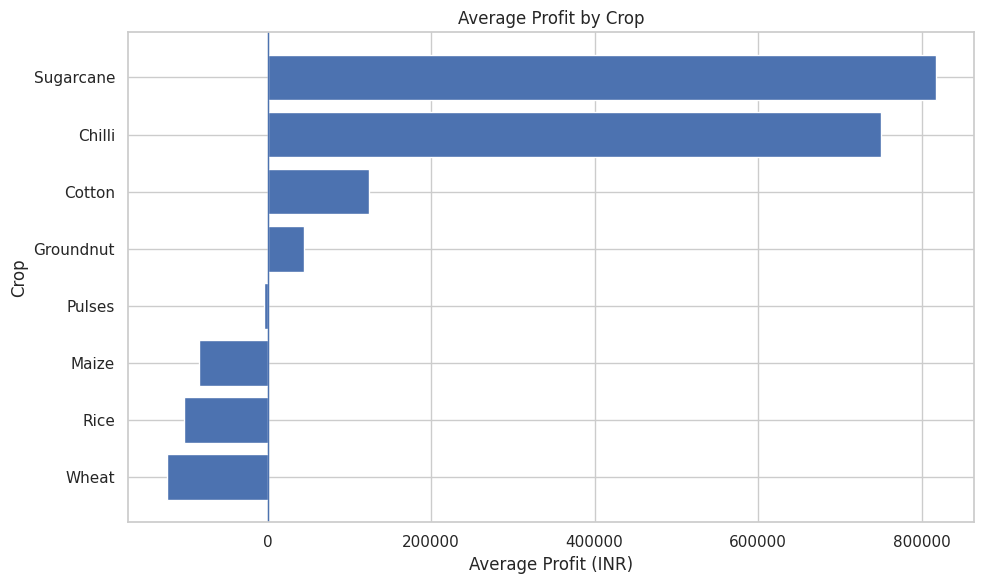

In [35]:
plt.figure(figsize=(10, 6))

crop_profit = crop_summary.sort_values("Profit_INR")

plt.barh(
    crop_profit.index,
    crop_profit["Profit_INR"]
)

plt.axvline(0, linewidth=1)

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [36]:
state_season = pd.pivot_table(
    df_clean,
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
)

state_season.round(2)

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


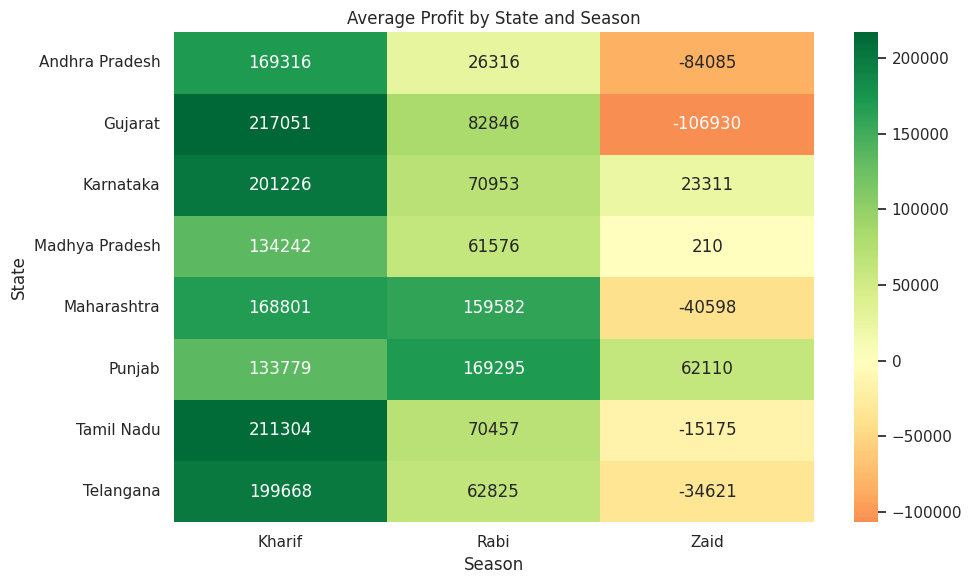

In [37]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    state_season,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.tight_layout()
plt.show()

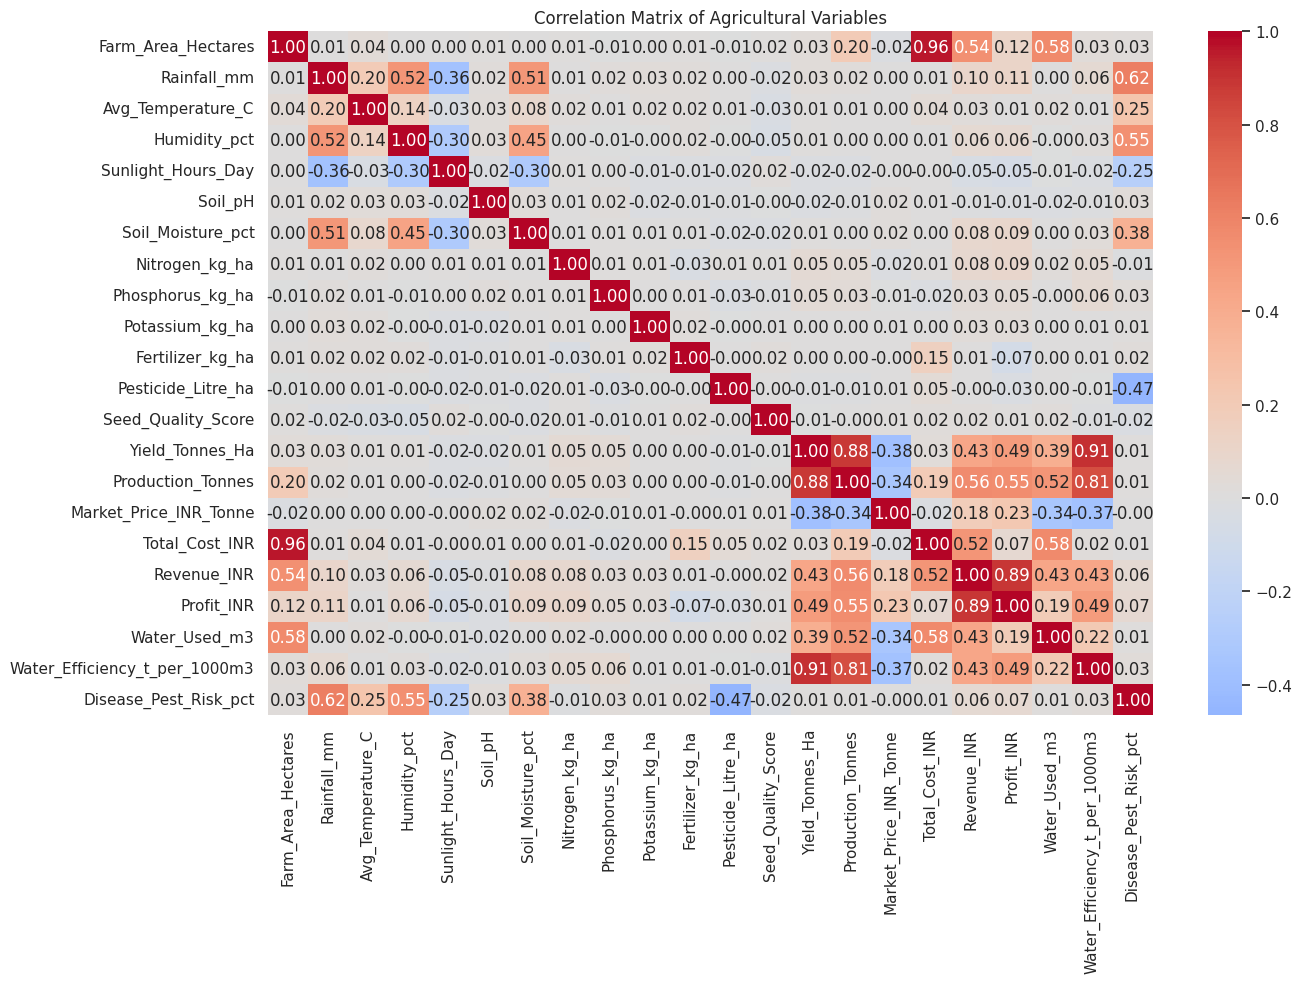

In [38]:
numeric_df = df_clean.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()
plt.show()

In [39]:
yield_correlation = correlation[
    "Yield_Tonnes_Ha"
].sort_values(ascending=False)

print(yield_correlation)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64


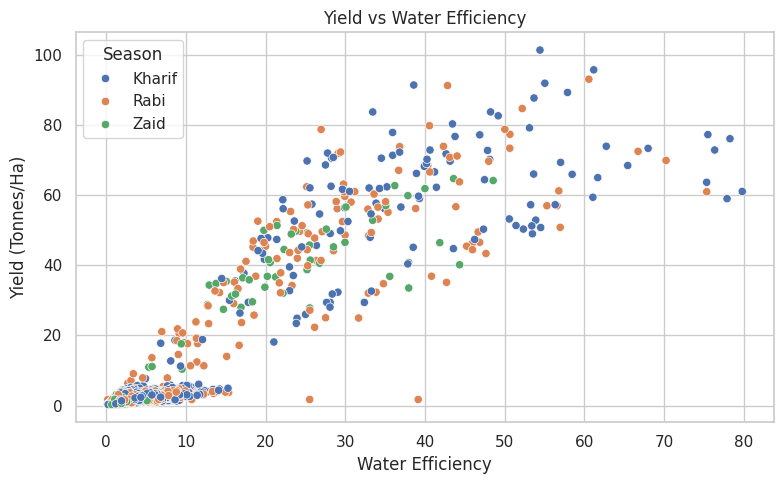

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Water_Efficiency_t_per_1000m3",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Yield vs Water Efficiency")
plt.xlabel("Water Efficiency")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [41]:
kharif = df_clean[
    df_clean["Season"] == "Kharif"
]["Yield_Tonnes_Ha"]

rabi = df_clean[
    df_clean["Season"] == "Rabi"
]["Yield_Tonnes_Ha"]

zaid = df_clean[
    df_clean["Season"] == "Zaid"
]["Yield_Tonnes_Ha"]

f_stat, p_value = stats.f_oneway(
    kharif,
    rabi,
    zaid
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [42]:
if p_value < 0.05:
    print(
        "Result: There is a statistically significant "
        "difference in average yield between seasons."
    )
else:
    print(
        "Result: No statistically significant difference "
        "in average yield between seasons was detected."
    )

Result: No statistically significant difference in average yield between seasons was detected.


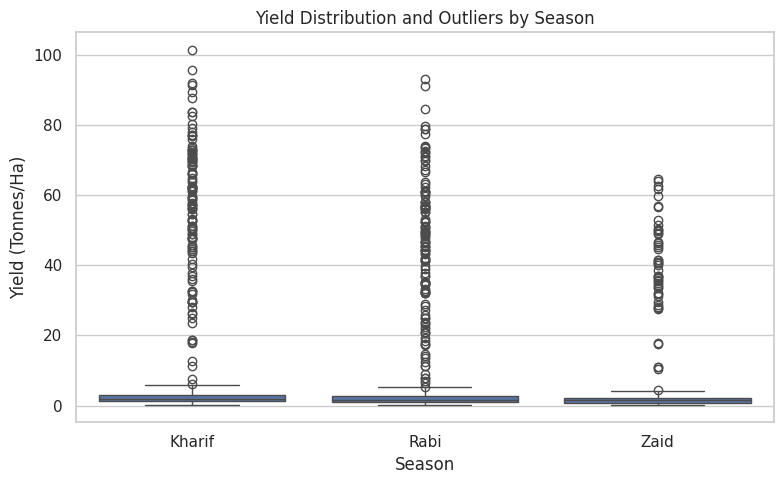

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution and Outliers by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

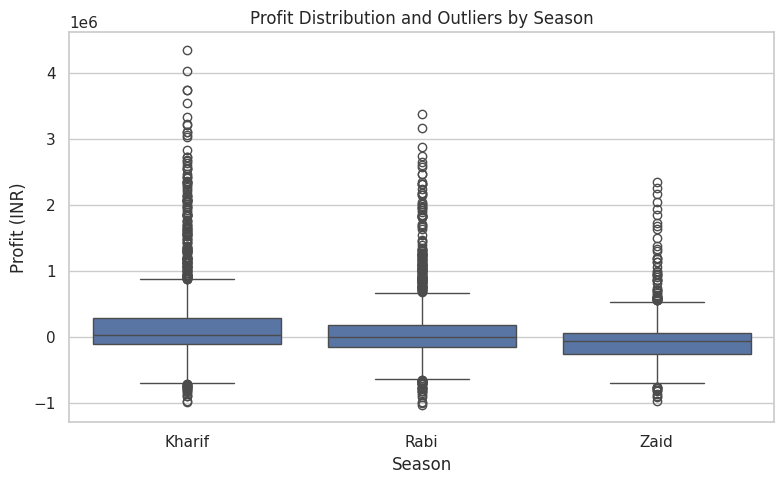

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution and Outliers by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

In [45]:
df_clean.to_csv(
    "seasonal_agriculture_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
